Seaborn is a Python data visualization library built on top of Matplotlib. It provides a high-level interface for creating attractive and informative statistical graphics with less code.

In [1]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
import seaborn as sns

In [5]:
##basic plotting with seaborn
tips=sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


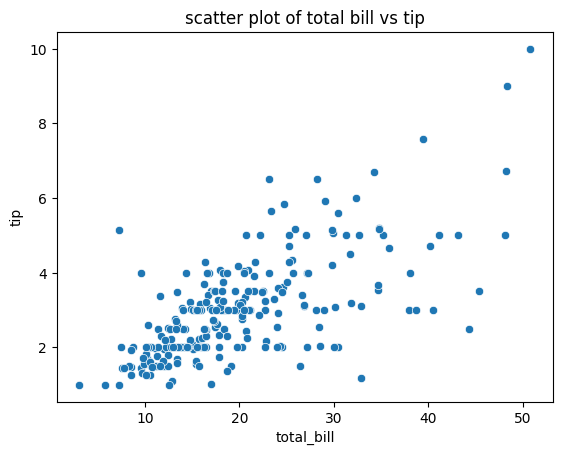

In [9]:
#scatter plot
import matplotlib.pyplot as plt
sns.scatterplot(x='total_bill',y='tip',data=tips)
plt.title('scatter plot of total bill vs tip')
plt.show()

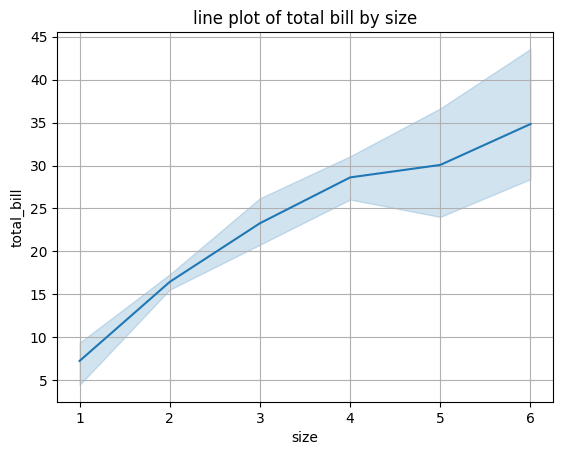

In [16]:
#line plot
sns.lineplot(x='size',y='total_bill',data=tips)
plt.grid()
plt.title('line plot of total bill by size')
plt.show()

The line plot shows that the average restaurant bill increases as the number of people in the party increases. There is a clear positive trend between party size and total bill amount. The shaded confidence interval indicates variability in bill amounts for each group size, with larger groups showing greater variation in spending.

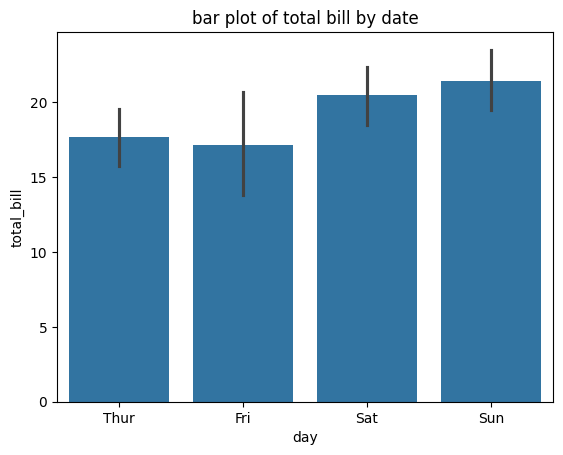

In [14]:
#categorical plots
##bar plot
sns.barplot(x='day',y='total_bill',data=tips)
plt.title('bar plot of total bill by date')
plt.show()

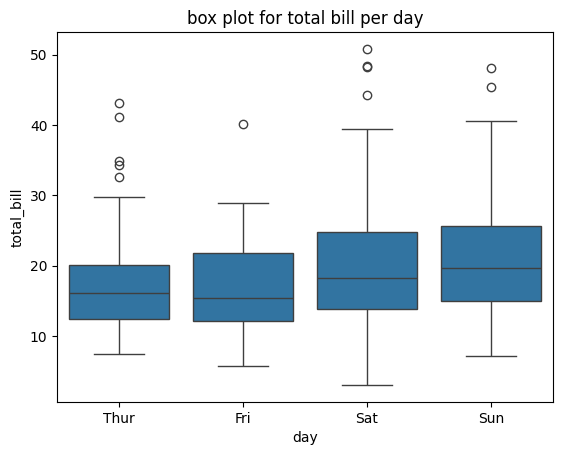

In [18]:
#box plot
sns.boxplot(x='day',y='total_bill',data=tips)
plt.title("box plot for total bill per day")
plt.show()

A box plot is used to visualize the distribution of numerical data. It displays the median, quartiles, spread, and potential outliers, making it useful for detecting anomalies and comparing distributions across different categories. For example, in the tips dataset, a box plot can show how restaurant bills vary across different days of the week.

<Axes: xlabel='day', ylabel='total_bill'>

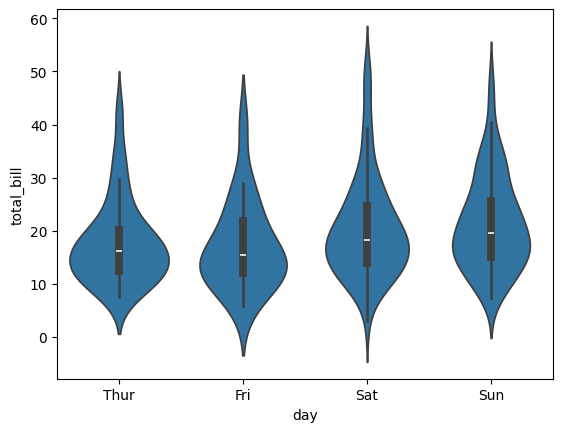

In [19]:
#violin plot 
sns.violinplot(x='day',y='total_bill',data=tips)

Easy Definition

Think of it as a box plot that gained weight where more data points exist.

The wider the violin at a particular value, the more observations are present there.

<Axes: xlabel='total_bill', ylabel='Count'>

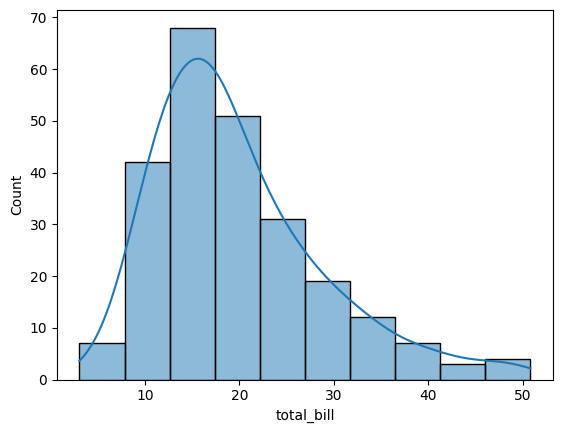

In [24]:
#histogram
sns.histplot(tips['total_bill'],bins=10,kde=True)

C:\Users\Soham Khade\AppData\Local\Temp\ipykernel_5676\575617140.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(tips['total_bill'],shade=True)


<Axes: xlabel='total_bill', ylabel='Density'>

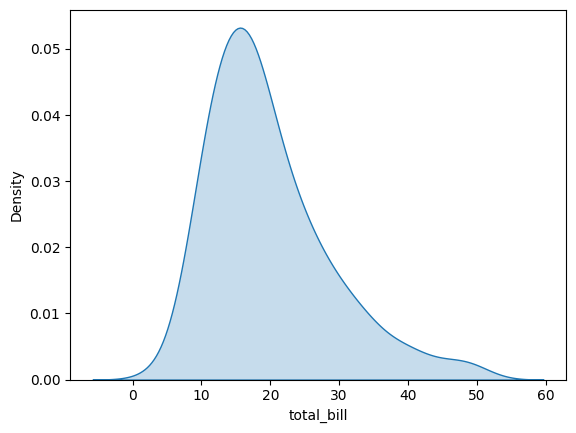

In [22]:
#kde plot
sns.kdeplot(tips['total_bill'],shade=True)

KDE Plot (Kernel Density Estimation)
Definition

A KDE plot is a smoothed version of a histogram used to visualize the distribution of a continuous variable.

Syntax
sns.kdeplot(df['column'], fill=True)

Used For
Understanding data distribution
Identifying skewness
Detecting multiple peaks (modes)
Finding where data is concentrated

Interpretation
Higher peak → More observations in that range
Wider curve → More spread
Multiple peaks → Multiple groups in data

In [26]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [27]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


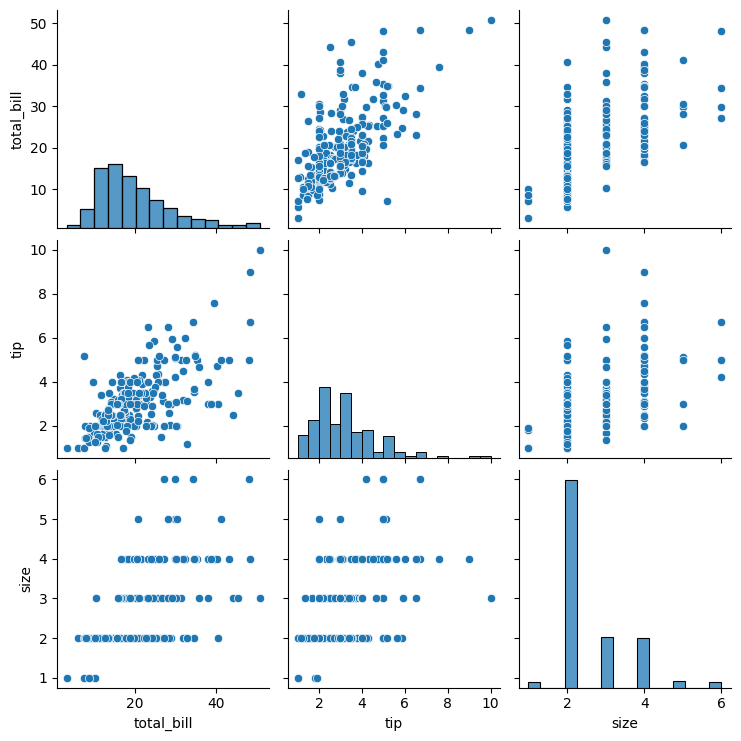

In [28]:
#pair plot
sns.pairplot(tips)

PLOT OF EVERY ATTRIBUTE TO EVERY OTHER ATTRIBUTE

In [ ]:
#HEATMAP
corr=tips[['total_bill','tip','size']].corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


#correlation it means how much is one feature or attribute depends on the other 

<Axes: >

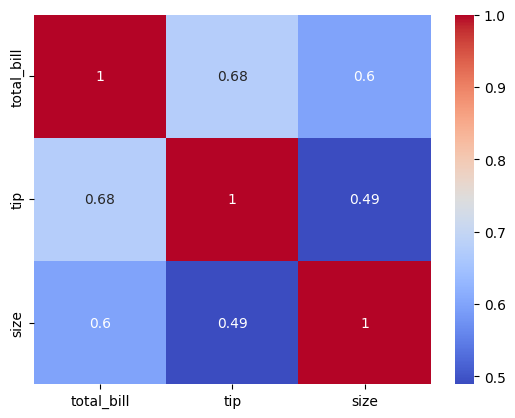

In [32]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [45]:
###implemention of this matplotlib with seaborn

import pandas as pd
sales_df=pd.read_csv('sales1.csv')
sales_df.columns = sales_df.columns.str.strip()
sales_df.head()

,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
0,Sweden,"17,524.02",14122.61,2/12/2020,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
1,Finland,"116,563.40",92807.78,9/26/2019,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2,Portugal,"296,465.56",257480.34,7/11/2019,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
3,Portugal,"74,532.02",59752.32,4/2/2020,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
4,Spain,"178,763.42",146621.76,12/22/2019,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


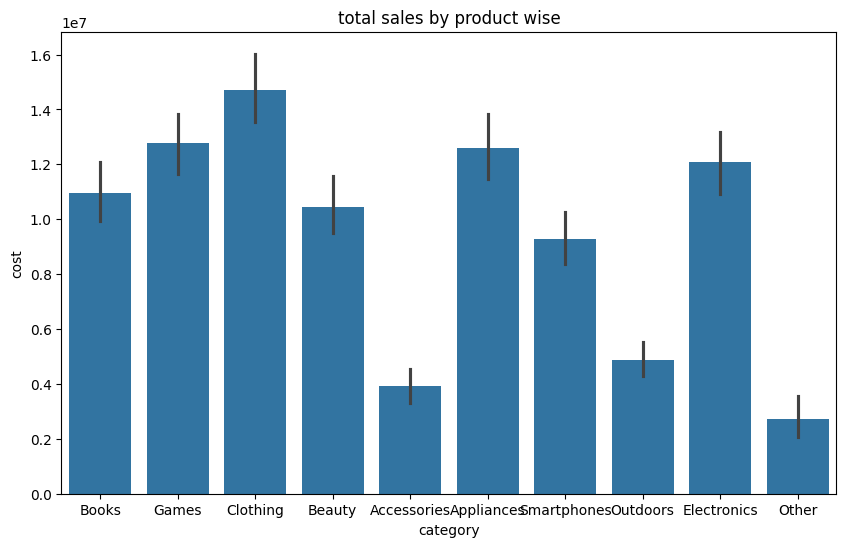

In [48]:
#plot total sales by product
plt.figure(figsize=(10,6))
sns.barplot(x='category',y='cost',data=sales_df,estimator=sum)
plt.xlabel('category')
plt.ylabel('cost')
plt.title('total sales by product wise')
plt.show()


In [47]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          1000 non-null   object 
 1   order_value_EUR  1000 non-null   object 
 2   cost             1000 non-null   float64
 3   date             1000 non-null   object 
 4   category         1000 non-null   object 
 5   customer_name    1000 non-null   object 
 6   sales_manager    1000 non-null   object 
 7   sales_rep        1000 non-null   object 
 8   device_type      1000 non-null   object 
 9   order_id         1000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 78.2+ KB


In [49]:
sales_df


,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
0,Sweden,"17,524.02",14122.61,2/12/2020,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
1,Finland,"116,563.40",92807.78,9/26/2019,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2,Portugal,"296,465.56",257480.34,7/11/2019,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
3,Portugal,"74,532.02",59752.32,4/2/2020,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
4,Spain,"178,763.42",146621.76,12/22/2019,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160
...,...,...,...,...,...,...,...,...,...,...
995,France,"46,296.26",40319.41,5/15/2020,Games,Wisoky Inc,Othello Bowes,Amelina Piscopiello,Tablet,77-3489084
996,Belgium,"118,061.05",101131.10,7/2/2020,Appliances,Johns and Sons,Lambert Norheny,Collin Mackness,Mobile,59-2117058
997,Finland,"74,480.56",60023.88,3/6/2020,Clothing,Homenick-Marvin,Hube Corey,Wat Bowkley,PC,31-1849120
998,Spain,"87,205.01",69171.01,6/18/2020,Games,Johns and Sons,Emalia Dinse,Manuel Goudie,Tablet,45-3085595
